In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

In [ ]:
master_data = pd.read_csv("/content/master_influenza_dataset.csv", parse_dates=["Date"])
master_data.head()

,Year,Week,ILI_Total,Total_Patients,Weighted_ILI,Region,Season,Date,Population_2024,ILI_per_100k
0,2019,40,5637,333469,1.67601,Region 4,2019_20,2019-09-30,70994814.0,7.940017
1,2019,41,5349,317260,1.63170,Region 4,2019_20,2019-10-07,70994814.0,7.534353
2,2019,42,5711,311644,1.81532,Region 4,2019_20,2019-10-14,70994814.0,8.044250
3,2019,43,6683,322052,1.96609,Region 4,2019_20,2019-10-21,70994814.0,9.413364
4,2019,44,7119,318970,2.29988,Region 4,2019_20,2019-10-28,70994814.0,10.027493


In [ ]:
print("Master data shape:", master_data.shape)
master_data.info()

Master data shape: (780, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 780 entries, 0 to 779
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Year             780 non-null    int64         
 1   Week             780 non-null    int64         
 2   ILI_Total        780 non-null    int64         
 3   Total_Patients   780 non-null    int64         
 4   Weighted_ILI     780 non-null    float64       
 5   Region           780 non-null    object        
 6   Season           780 non-null    object        
 7   Date             780 non-null    datetime64[ns]
 8   Population_2024  780 non-null    float64       
 9   ILI_per_100k     780 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(4), object(2)
memory usage: 61.1+ KB


In [ ]:
gdf = gpd.read_file("/content/us_states.geojson")
gdf.head()

,GEO_ID,STATE,NAME,LSAD,CENSUSAREA,geometry
0,0400000US23,23,Maine,,30842.923,"MULTIPOLYGON (((-67.61976 44.51975, -67.61541 ..."
1,0400000US25,25,Massachusetts,,7800.058,"MULTIPOLYGON (((-70.83204 41.6065, -70.82374 4..."
2,0400000US26,26,Michigan,,56538.901,"MULTIPOLYGON (((-88.68443 48.11578, -88.67563 ..."
3,0400000US30,30,Montana,,145545.801,"POLYGON ((-104.0577 44.99743, -104.25014 44.99..."
4,0400000US32,32,Nevada,,109781.180,"POLYGON ((-114.0506 37.0004, -114.05 36.95777,..."


In [ ]:
gdf.columns

Index(['GEO_ID', 'STATE', 'NAME', 'LSAD', 'CENSUSAREA', 'geometry'], dtype='object')

In [ ]:
state_to_region = {
    "Alabama": "Region 4",
    "Florida": "Region 4",
    "Georgia": "Region 4",
    "Kentucky": "Region 4",
    "Mississippi": "Region 4",
    "North Carolina": "Region 4",
    "South Carolina": "Region 4",
    "Tennessee": "Region 4",

    "Arkansas": "Region 6",
    "Louisiana": "Region 6",
    "New Mexico": "Region 6",
    "Oklahoma": "Region 6",
    "Texas": "Region 6",

    "Arizona": "Region 9",
    "California": "Region 9",
    "Hawaii": "Region 9",
    "Nevada": "Region 9"
}

In [ ]:
gdf["Region"] = gdf["NAME"].map(state_to_region)
gdf[["NAME", "Region"]].head(20)

,NAME,Region
0,Maine,NaN
1,Massachusetts,NaN
2,Michigan,NaN
3,Montana,NaN
4,Nevada,Region 9
5,New Jersey,NaN
6,New York,NaN
7,North Carolina,Region 4
8,Ohio,NaN
9,Pennsylvania,NaN


In [ ]:
gdf_regions = gdf[gdf["Region"].notna()].copy()
gdf_regions[["NAME", "Region"]].head(20)

,NAME,Region
4,Nevada,Region 9
7,North Carolina,Region 4
11,Tennessee,Region 4
12,Texas,Region 6
18,Alabama,Region 4
20,Arizona,Region 9
21,Arkansas,Region 6
22,California,Region 9
27,Florida,Region 4
28,Georgia,Region 4


In [ ]:
cumulative_burden = master_data.groupby("Region", as_index=False)["ILI_Total"].sum()
cumulative_burden

,Region,ILI_Total
0,Region 4,4474993
1,Region 6,1227695
2,Region 9,2296799


In [ ]:
gdf_cumulative = gdf_regions.merge(cumulative_burden, on="Region", how="left")
gdf_cumulative.head()

,GEO_ID,STATE,NAME,LSAD,CENSUSAREA,geometry,Region,ILI_Total
0,0400000US32,32,Nevada,,109781.180,"POLYGON ((-114.0506 37.0004, -114.05 36.95777,...",Region 9,2296799
1,0400000US37,37,North Carolina,,48617.905,"MULTIPOLYGON (((-82.60288 36.03983, -82.60074 ...",Region 4,4474993
2,0400000US47,47,Tennessee,,41234.896,"POLYGON ((-81.67754 36.58812, -81.68014 36.585...",Region 4,4474993
3,0400000US48,48,Texas,,261231.711,"MULTIPOLYGON (((-97.13436 27.89633, -97.1336 2...",Region 6,1227695
4,0400000US01,01,Alabama,,50645.326,"MULTIPOLYGON (((-85.00237 31.00068, -85.02411 ...",Region 4,4474993


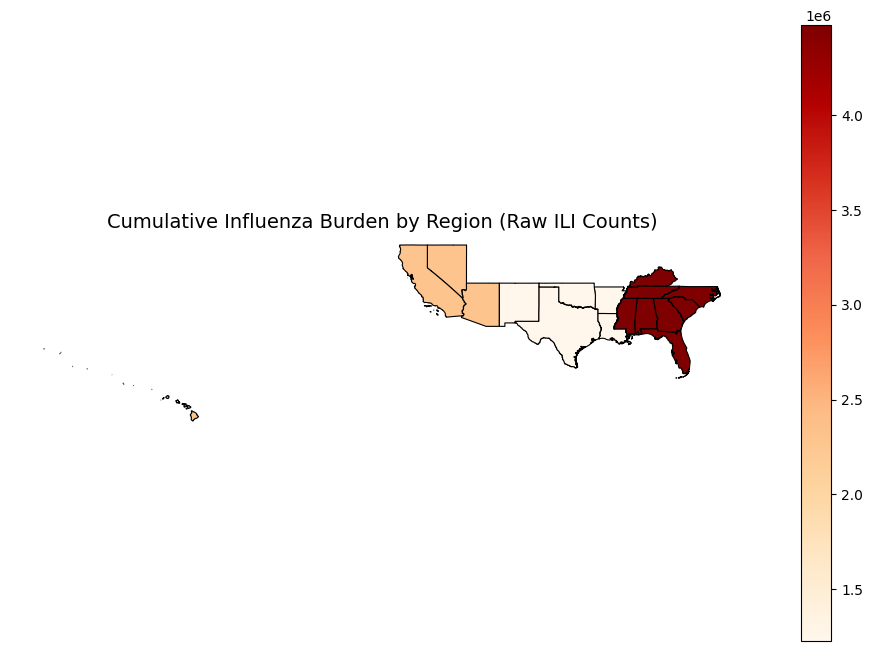

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

gdf_cumulative.plot(
    column="ILI_Total",
    cmap="OrRd",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title("Cumulative Influenza Burden by Region (Raw ILI Counts)", fontsize=14)
ax.axis("off")
plt.show()

In [ ]:
percap_burden = master_data.groupby("Region", as_index=False)["ILI_per_100k"].sum()
percap_burden

,Region,ILI_per_100k
0,Region 4,6303.267447
1,Region 6,2715.984714
2,Region 9,4440.210056


In [ ]:
gdf_percap = gdf_regions.merge(percap_burden, on="Region", how="left")
gdf_percap.head()

,GEO_ID,STATE,NAME,LSAD,CENSUSAREA,geometry,Region,ILI_per_100k
0,0400000US32,32,Nevada,,109781.180,"POLYGON ((-114.0506 37.0004, -114.05 36.95777,...",Region 9,4440.210056
1,0400000US37,37,North Carolina,,48617.905,"MULTIPOLYGON (((-82.60288 36.03983, -82.60074 ...",Region 4,6303.267447
2,0400000US47,47,Tennessee,,41234.896,"POLYGON ((-81.67754 36.58812, -81.68014 36.585...",Region 4,6303.267447
3,0400000US48,48,Texas,,261231.711,"MULTIPOLYGON (((-97.13436 27.89633, -97.1336 2...",Region 6,2715.984714
4,0400000US01,01,Alabama,,50645.326,"MULTIPOLYGON (((-85.00237 31.00068, -85.02411 ...",Region 4,6303.267447


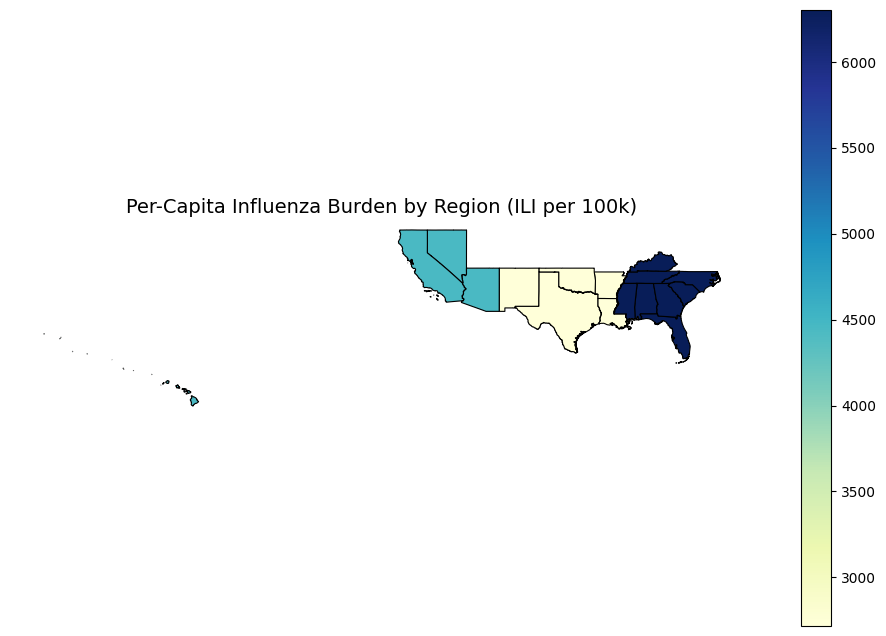

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

gdf_percap.plot(
    column="ILI_per_100k",
    cmap="YlGnBu",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title("Per-Capita Influenza Burden by Region (ILI per 100k)", fontsize=14)
ax.axis("off")
plt.show()

In [ ]:
spatial_summary = master_data.groupby("Region").agg({
    "ILI_Total": "sum",
    "Weighted_ILI": "mean",
    "ILI_per_100k": "sum"
}).reset_index()

spatial_summary.columns = ["Region", "Total_ILI", "Avg_Weighted_ILI", "Total_ILI_per_100k"]
spatial_summary

,Region,Total_ILI,Avg_Weighted_ILI,Total_ILI_per_100k
0,Region 4,4474993,3.126246,6303.267447
1,Region 6,1227695,3.550187,2715.984714
2,Region 9,2296799,2.797938,4440.210056


In [ ]:
spatial_summary.to_csv("/content/spatial_summary_table.csv", index=False)
print("Saved as spatial_summary_table.csv")

Saved as spatial_summary_table.csv


In [ ]:
peak_weeks = master_data.loc[master_data.groupby("Region")["Weighted_ILI"].idxmax()][
    ["Region", "Date", "Weighted_ILI"]
]
peak_weeks

,Region,Date,Weighted_ILI
168,Region 4,2023-12-25,9.71012
272,Region 6,2019-12-23,13.40260
740,Region 9,2024-12-23,8.64684


In [ ]:
early_phase = master_data.groupby("Region", as_index=False).first()[["Region", "Date", "Weighted_ILI"]]
late_phase = master_data.groupby("Region", as_index=False).last()[["Region", "Date", "Weighted_ILI"]]

early_phase.rename(columns={"Weighted_ILI": "Early_ILI"}, inplace=True)
peak_weeks.rename(columns={"Weighted_ILI": "Peak_ILI"}, inplace=True)
late_phase.rename(columns={"Weighted_ILI": "Late_ILI"}, inplace=True)

early_phase, peak_weeks, late_phase

(     Region       Date  Early_ILI
 0  Region 4 2019-09-30    1.67601
 1  Region 6 2019-09-30    2.17009
 2  Region 9 2019-09-30    1.30845,
        Region       Date  Peak_ILI
 168  Region 4 2023-12-25   9.71012
 272  Region 6 2019-12-23  13.40260
 740  Region 9 2024-12-23   8.64684,
      Region       Date  Late_ILI
 0  Region 4 2025-09-22   1.82518
 1  Region 6 2025-09-22   2.24982
 2  Region 9 2025-09-22   2.02152)

In [ ]:
gdf_phase = gdf_regions.merge(early_phase[["Region", "Early_ILI"]], on="Region", how="left")
gdf_phase = gdf_phase.merge(peak_weeks[["Region", "Peak_ILI"]], on="Region", how="left")
gdf_phase = gdf_phase.merge(late_phase[["Region", "Late_ILI"]], on="Region", how="left")

gdf_phase.head()

,GEO_ID,STATE,NAME,LSAD,CENSUSAREA,geometry,Region,Early_ILI,Peak_ILI,Late_ILI
0,0400000US32,32,Nevada,,109781.180,"POLYGON ((-114.0506 37.0004, -114.05 36.95777,...",Region 9,1.30845,8.64684,2.02152
1,0400000US37,37,North Carolina,,48617.905,"MULTIPOLYGON (((-82.60288 36.03983, -82.60074 ...",Region 4,1.67601,9.71012,1.82518
2,0400000US47,47,Tennessee,,41234.896,"POLYGON ((-81.67754 36.58812, -81.68014 36.585...",Region 4,1.67601,9.71012,1.82518
3,0400000US48,48,Texas,,261231.711,"MULTIPOLYGON (((-97.13436 27.89633, -97.1336 2...",Region 6,2.17009,13.40260,2.24982
4,0400000US01,01,Alabama,,50645.326,"MULTIPOLYGON (((-85.00237 31.00068, -85.02411 ...",Region 4,1.67601,9.71012,1.82518


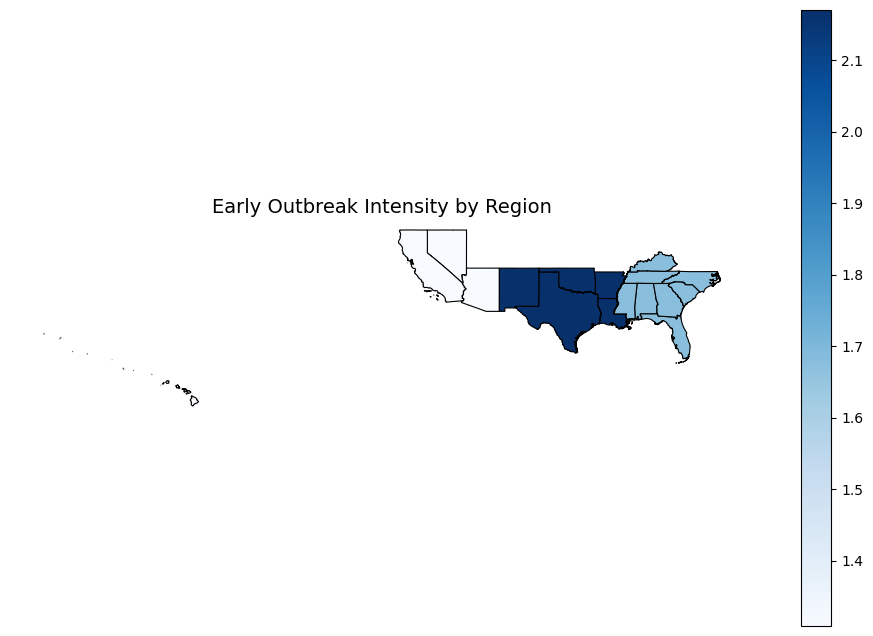

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

gdf_phase.plot(
    column="Early_ILI",
    cmap="Blues",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title("Early Outbreak Intensity by Region", fontsize=14)
ax.axis("off")
plt.show()

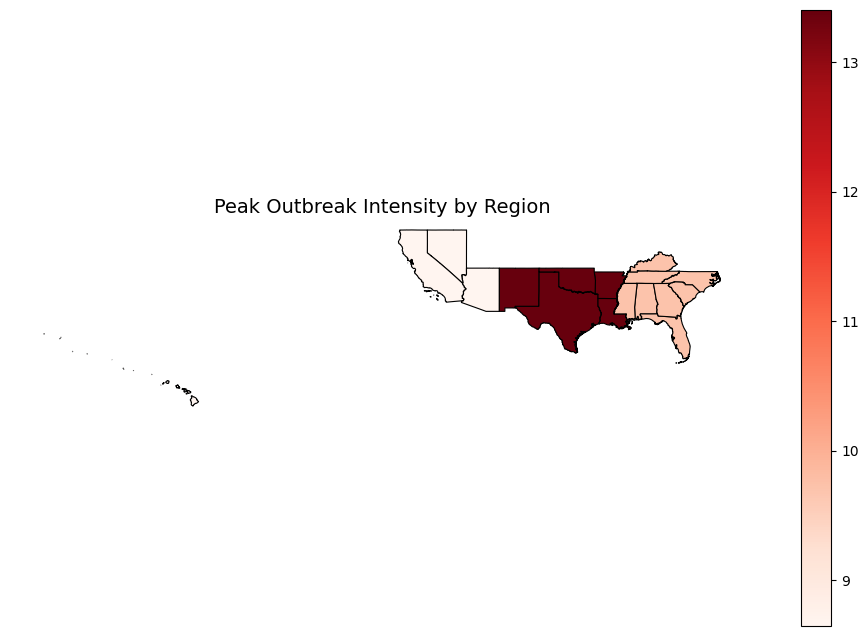

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

gdf_phase.plot(
    column="Peak_ILI",
    cmap="Reds",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title("Peak Outbreak Intensity by Region", fontsize=14)
ax.axis("off")
plt.show()

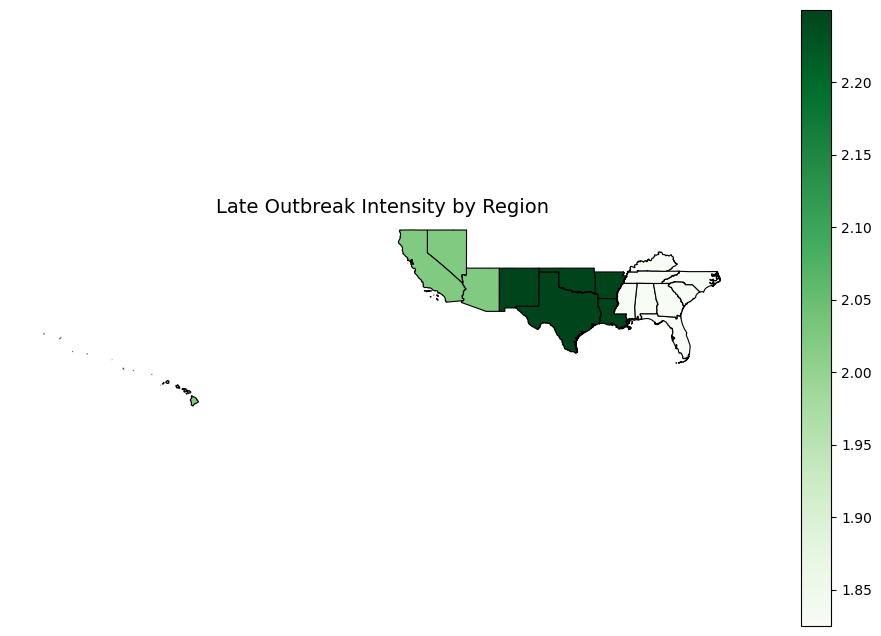

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

gdf_phase.plot(
    column="Late_ILI",
    cmap="Greens",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title("Late Outbreak Intensity by Region", fontsize=14)
ax.axis("off")
plt.show()

In [ ]:
phase_summary = early_phase.rename(columns={"Date": "Early_Date"}).merge(
    peak_weeks.rename(columns={"Date": "Peak_Date"})[["Region", "Peak_Date", "Peak_ILI"]],
    on="Region",
    how="left"
)

phase_summary = phase_summary.merge(
    late_phase.rename(columns={"Date": "Late_Date"})[["Region", "Late_Date", "Late_ILI"]],
    on="Region",
    how="left"
)

phase_summary.to_csv("/content/phase_summary_table.csv", index=False)
phase_summary

,Region,Early_Date,Early_ILI,Peak_Date,Peak_ILI,Late_Date,Late_ILI
0,Region 4,2019-09-30,1.67601,2023-12-25,9.71012,2025-09-22,1.82518
1,Region 6,2019-09-30,2.17009,2019-12-23,13.40260,2025-09-22,2.24982
2,Region 9,2019-09-30,1.30845,2024-12-23,8.64684,2025-09-22,2.02152


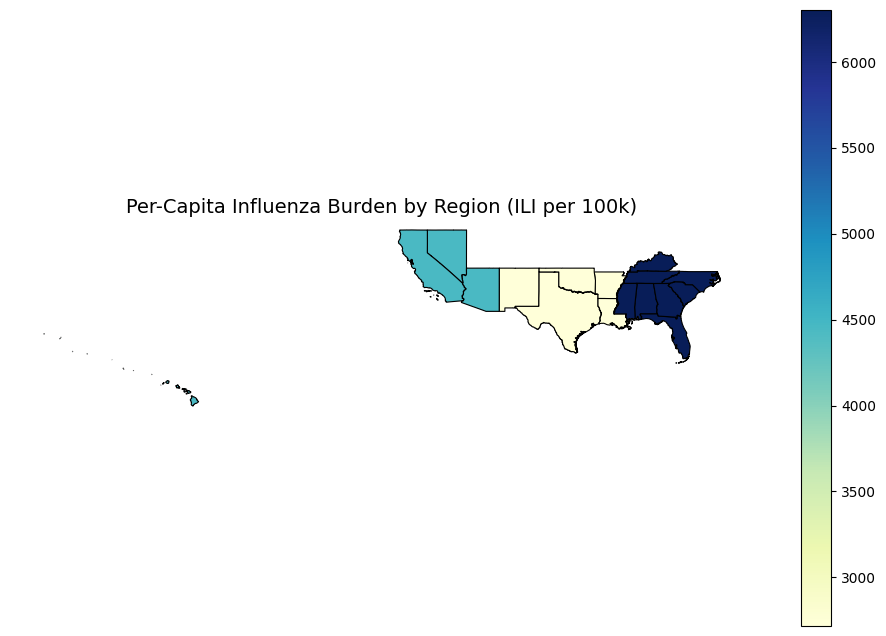

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

gdf_percap.plot(
    column="ILI_per_100k",
    cmap="YlGnBu",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title("Per-Capita Influenza Burden by Region (ILI per 100k)", fontsize=14)
ax.axis("off")

plt.savefig("/content/per_capita_burden_map.png", dpi=300, bbox_inches="tight")
plt.show()